__TESTING & VALIDATING ZONE__

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from datetime import datetime
import glob
from invisible_cities.reco.corrections import read_maps
from invisible_cities.reco.corrections import apply_all_correction
from invisible_cities.types.symbols    import NormStrategy
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Preliminary

In [2]:
# ----- Type of Analysis ----- #
ANALYSIS_TYPE = 'Cathode'                       # Options: 'All', 'Cathode'
DATE = datetime.now().strftime('%d%m%Y')        # Current Date
# DATE = '01122025'                             # Specific Date

In [3]:
# --------------------------------------------
# 1. MC DIRECTORIES, PATHS, KEYS AND FILENAMES
# --------------------------------------------
MC_PATHS = []
if ANALYSIS_TYPE == 'All':

    MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/'
    # Get all subfolders in MC_DIR
    VOLUMES = [folder for folder in os.listdir(MC_DIR) if os.path.isdir(os.path.join(MC_DIR, folder)) and folder != 'CATHODE_SURF']
    for volume in sorted(VOLUMES):
        # Get all sophronia files in the volume subfolder
        sophronia_files = sorted(glob.glob(os.path.join(MC_DIR, volume, 'sophronia', '*.sophronia.h5')))
        # print(f"  Found {len(sophronia_files)} sophronia files in {volume}")
        if sophronia_files:
            MC_PATHS.extend(sophronia_files)
        else:
            print(f"No sophronia files found in {volume}")
    # Sort the final list of paths
    MC_PATHS = sorted(MC_PATHS)
    print(f"Total sophronia files to process: {len(MC_PATHS)}")

elif ANALYSIS_TYPE == 'Cathode':

    MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/CATHODE_SURF/sophronia/'
    MC_PATHS = sorted(glob.glob(MC_DIR + '*.sophronia.h5'))
    print(f"Total sophronia files to process: {len(MC_PATHS)}")

else:
    
    raise ValueError("Invalid ANALYSIS_TYPE. Choose 'All' or 'Cathode'.")

# KEYS
NEXUS_KEY = '/MC/configuration'
DORO_KEY = '/DST/Events'
SOPH_KEY = '/RECO/Events'

# COLIUMNS TO USE
doro_columns = ['event', 'time', 'nS1', 'nS2', 'S1h', 'S1e', 'S2e', 'S2q', 'DT', 'X', 'Y', 'Z']
soph_columns = ['event', 'time', 'npeak', 'X', 'Xpeak', 'Y', 'Z', 'Q', 'Ec']

# OUTPUT
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/'
OUTPUT_H5  = 'processed_MC_background_' + ANALYSIS_TYPE + '_' + DATE + '.h5'
print(f"Output will be saved to: {os.path.join(OUTPUT_DIR, OUTPUT_H5)}")

# ------------------------
# 2. PROCESSING PARAMETERS
# ------------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- Trigger 2 Efficiency ---
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5         # in [MeV]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
DT_STOP = 1372.2543          # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values for S1e correction vs DT

# --- Alpha/Electron Separation Cut ---
# Events with total corrected energy above this threshold are classified as alphas.
ENERGY_THRESHOLD_PE = 7.5e5       # in [PE]

# --- HE Scale Correction ---
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094
ENERGY_THRESHOLD_MEV = M_HE_SCALE * ENERGY_THRESHOLD_PE + B_HE_SCALE   # in [MeV]

# --- Hits Clusterizer Configuration ---
CLUSTER_CONFIG = {"eps": 3, "min_samples": 5}

# -------------------
# 3. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

Total sophronia files to process: 5000
Output will be saved to: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/processed_MC_background_Cathode_17122025.h5


# Reconstruction

In [4]:
# Initialize empty lists to store the dataframes
run_dst  = []
run_reco = []
doro_counter, soph_counter = 0, 0

# ----- File Loop ----- #
for h5_path in MC_PATHS[:50]:

    # print(f"--- Processing {h5_path} ---")

    try:
        # ----- Dorothea ----- #
        dst_df = pd.read_hdf(h5_path, key=DORO_KEY)
        # dst_df = dst_df.loc[:, doro_columns]          # Activate this when you are completely sure!
        doro_counter += dst_df['event'].nunique()
        run_dst.append(dst_df)

        # ----- Sophronia ----- #
        reco_df = pd.read_hdf(h5_path, key=SOPH_KEY)
        # reco_df = reco_df.loc[:, soph_columns]
        soph_counter += reco_df['event'].nunique()
        run_reco.append(reco_df)

    except KeyError as e:
        print(f"Warning: Key '{e.args[0]}' not found in file '{h5_path}'. Skipping this file.")

# ----- Concatenate Data ----- #
test_doro = pd.DataFrame()
test_soph = pd.DataFrame()

if run_dst:
    test_doro = pd.concat(run_dst, ignore_index=True)

if run_reco:
    test_soph = pd.concat(run_reco, ignore_index=True)

# ----- Print Summary ----- #
print(f"--- You have loaded {len(run_dst)} files ---")
print(f"Dorothea events  = {doro_counter}")
print(f"Sophronia events = {soph_counter}")

--- You have loaded 50 files ---
Dorothea events  = 2820
Sophronia events = 2780


#### Why are those numbers different?

If the $S2$ signal is not strong enough to activate the SiPMs (lower charge than the threshold), a false hit is created with negative values in $XYZ$ but the energy of the corresponding slice is stored.
<br>
__Hyp:__ Sophronia ignores pairs with _weak_ $S2$ signals.

In [5]:
# Events with weak S2: Dorothea info
weak_S2_in_doro_ids = test_doro.loc[test_doro['S2q'] < 0, 'event'].unique()

# Dataframes with events of interest
doro_subset = test_doro[test_doro['event'].isin(weak_S2_in_doro_ids)].copy()
soph_subset = test_soph[test_soph['event'].isin(weak_S2_in_doro_ids)].copy()

# Count the unique peaks in these dataframes
peak_count_doro = doro_subset.groupby('event')['s2_peak'].nunique()
peak_count_soph = soph_subset.groupby('event')['npeak'].nunique()

# Comparison dataframe: index is event ID
comparison_df = pd.DataFrame(
                                {   
                                    'nS2_doro': peak_count_doro,
                                    'nS2_soph': peak_count_soph
                                }
                            ).fillna(-1)  # Fill NaN with -1

matching_mask = (comparison_df['nS2_doro'] == comparison_df['nS2_soph'])

# Events with weak S2 in Dorothea that also match in Sophronia
weak_S2_in_soph_ids = comparison_df[matching_mask].index.values

print(f"From {len(weak_S2_in_doro_ids)} events with at least one weak S2 in Dorothea, "
      f"{len(weak_S2_in_soph_ids)} have the same number of S2 peaks in Sophronia.")

From 980 events with at least one weak S2 in Dorothea, 0 have the same number of S2 peaks in Sophronia.


#### -
Most (or all) of the pairs with $S2$ weak are ignored in Sophronia.
<br>
If Sophronia ignored all the weak $S2$, do not follow these cells.

In [6]:
hits_S2_weak = []
hits_S2_norm = []

for evt_id in weak_S2_in_soph_ids:

    print(f"--- Event {evt_id}: ---")

    # Sophronia
    df_soph_npeak = test_soph[test_soph['event'] == evt_id].groupby('npeak')

    for npeak_id, group in df_soph_npeak:

        if (group['Xpeak'] < -5000).any():  # These are the weak S2 peaks
            hits_S2_weak.append(len(group))
            print(f"  Peak {npeak_id} is weak and has {len(group)} hits.")
        else:
            hits_S2_norm.append(len(group))

In [ ]:
# Global
min_hits = min(min(hits_S2_weak), min(hits_S2_norm))
max_hits = max(max(hits_S2_weak), max(hits_S2_norm))
bins = np.arange(min_hits, max_hits + 2)

# Histogram for hits_S2_weak
hits_weak_counts, hits_weak_edges = np.histogram(hits_S2_weak, bins=bins)

# Histogram for hits_S2_norm
hits_norm_counts, hits_norm_edges = np.histogram(hits_S2_norm, bins=bins)

# Plotting
plt.figure(figsize=(8, 6))
plt.stairs(hits_weak_counts, hits_weak_edges, fill=False, lw=1.5, ec='blue', label='Weak S2 Peaks')
plt.stairs(hits_norm_counts, hits_norm_edges, fill=False, lw=1.5, ec='green', label='Normal S2 Peaks')

# Styling
plt.xlabel('Number of Hits')
# plt.xlim(0, 100)
plt.ylabel('Counts')
plt.title('Hits Multiplicity per S2 Peak')
plt.legend()

plt.grid(True, ls='--', lw=0.5, alpha=0.5)
plt.gca().set_facecolor("whitesmoke")
plt.show()

In any case, I will ignore all these weak $S2$ peaks.

## Strong $S2$ Signal

In [7]:
# Remove weak S2 peaks in Dorothea and Sophronia
test_doro = test_doro[test_doro['S2q'] >= 0].copy()
test_soph = test_soph[test_soph['Xpeak'] >= -5000].copy()
strong_S2_in_soph_ids = test_soph['event'].unique()
print(f"After removing weak S2 peaks: {len(strong_S2_in_soph_ids)} events ({len(strong_S2_in_soph_ids)/soph_counter:.2%})")

# Update dataframe
test_doro = test_doro[test_doro['event'].isin(strong_S2_in_soph_ids)].copy()
print(f"Dorothea events: {test_doro['event'].nunique()}")

After removing weak S2 peaks: 2780 events (100.00%)
Dorothea events: 2780


## Energy Correction

MC file are already corrected, so we just cluean negative/NaN energies.

In [8]:
print(f"Before clean hits with NaN or negative energy: {test_soph.shape[0]} hits")
# Set hits with NaN or negative energy to 0
test_soph['Ec'] = np.where(
                                pd.notna(test_soph['Ec']) & (test_soph['Ec'] > 0),        # Condition
                                test_soph['Ec'],                                          # Value if condition is True
                                0                                                         # Value if condition is False   
)

# Update dataframes
positive_Ec_ids = test_soph['event'].unique()
test_doro, test_soph = bf.apply_cut_and_update(test_doro, test_soph, event_ids=positive_Ec_ids)
print(f"After set hits with NaN or negative energy to 0: {len(positive_Ec_ids)} events ({len(positive_Ec_ids)/len(strong_S2_in_soph_ids):.2%}), {test_soph.shape[0]} hits")

Before clean hits with NaN or negative energy: 3764466 hits
After set hits with NaN or negative energy to 0: 2780 events (100.00%), 3764466 hits


## $S1$ Signal

In [9]:
test_doro['nS1'].value_counts()

1    3515
0     412
2      18
Name: nS1, dtype: int64

~~I would not expect events with $0\,S1$ (anode-like), let's see some of them.~~
<br>
Well, we can always have anode events or mis-reconstructed cathode events (they lose their S1 sometimes).

In [10]:
evts_NO_S1 = test_doro.loc[test_doro['nS1'] == 0, 'event'].unique()
print(f"With nS1 = 0: {len(evts_NO_S1)} events")

With nS1 = 0: 352 events


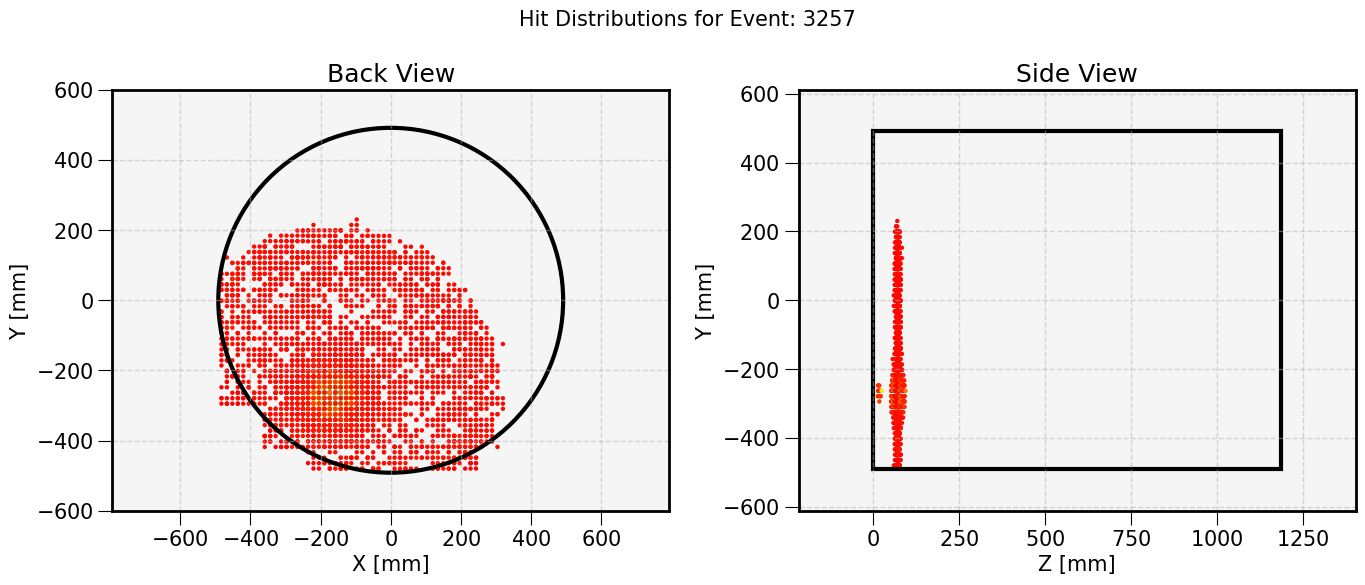

In [18]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(evts_NO_S1))

In [12]:
# nS1 <= 1
data_S1 = test_doro[test_doro['nS1'] <= 1].copy()
zero_s1_ids = data_S1.loc[data_S1['nS1'] == 0, 'event'].unique()
one_s1_ids  = data_S1.loc[data_S1['nS1'] == 1, 'event'].unique()
print(f"From {data_S1['event'].nunique()} events with nS1 ≤ 1: [{len(zero_s1_ids)} have nS1 = 0] & [{len(one_s1_ids)} have nS1 = 1]")

From 2775 events with nS1 ≤ 1: [352 have nS1 = 0] & [2423 have nS1 = 1]


#### How does the $S1$ behave?

In [13]:
# Wanna see how behaves nS1 = 1 events
data_one_s1 = test_doro[test_doro['nS1'] == 1].copy()

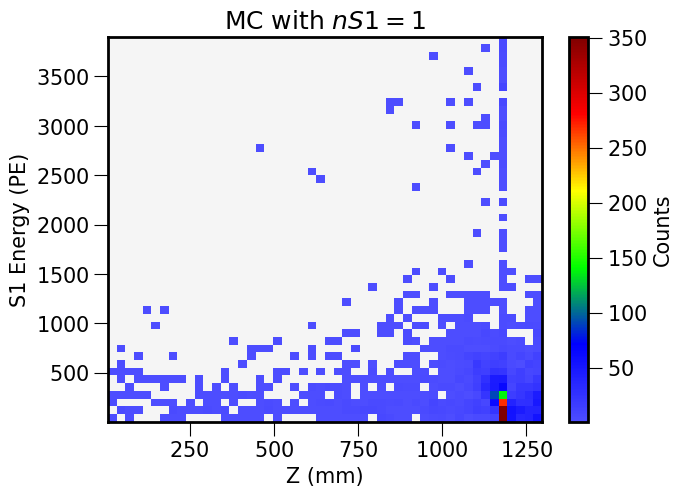

In [19]:
# Global
n_bins = 50

# Variables
E1 = data_one_s1['S1e']
Z  = data_one_s1['Z']

# 2D histogram
S1e_Z_map, ex, ey = np.histogram2d(Z, E1, bins=n_bins)
S1e_Z_map         = np.ma.masked_where(S1e_Z_map==0, S1e_Z_map)     # Zero values masked

# Plotting
plt.figure(figsize=(7, 5))
plt.pcolormesh(ex, ey, S1e_Z_map.T, cmap=pt.custom_hsv, shading='auto')

# Sytling
cbar = plt.colorbar(label='Counts')
plt.xlabel('Z (mm)')
plt.ylabel('S1 Energy (PE)')
plt.title(r'MC with $nS1 = 1$')
plt.gca().set_facecolor("whitesmoke")
plt.show()

Correct $S1$ energy

In [20]:
data_one_s1 = crudo.correct_S1e(data_one_s1, CV_FIT, DT_STOP, output_column='S1e_corr')

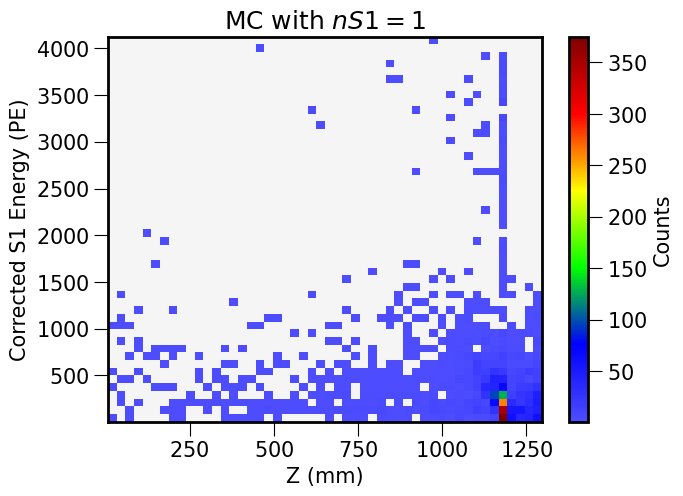

In [21]:
# Global
n_bins = 50

# Variables
E1 = data_one_s1['S1e_corr']
Z  = data_one_s1['Z']

# 2D histogram
S1e_Z_map, ex, ey = np.histogram2d(Z, E1, bins=n_bins)
S1e_Z_map         = np.ma.masked_where(S1e_Z_map==0, S1e_Z_map)     # Zero values masked

# Plotting
plt.figure(figsize=(7, 5))
plt.pcolormesh(ex, ey, S1e_Z_map.T, cmap=pt.custom_hsv, shading='auto')

# Sytling
cbar = plt.colorbar(label='Counts')
plt.xlabel('Z (mm)')
plt.ylabel('Corrected S1 Energy (PE)')
plt.title(r'MC with $nS1 = 1$')
plt.gca().set_facecolor("whitesmoke")
plt.show()

__It seems to have a problem with MC of Bi @ Cathode__
<br>
In any case, let's see information at event/peak level

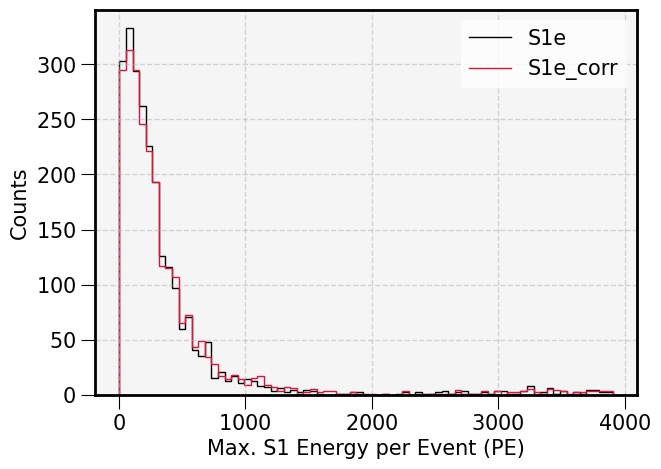

In [22]:
# Global
n_bins = 75

# Histogram
_, s1e_edges = np.histogram(data_one_s1['S1e'], bins=n_bins)
# print(f"S1e edges: {s1e_edges}")

plt.figure(figsize=(7, 5))
for i, col in enumerate(['S1e', 'S1e_corr']):

    S1e_event = data_one_s1.groupby('event')[col].max()         # Max. S1e per event
    s1e_counts, _ = np.histogram(S1e_event, bins=s1e_edges)

    # Plotting
    plt.stairs(s1e_counts, s1e_edges, label=col,
               fill=False, lw=1.0, ec=pt.hist_colors[i % len(pt.hist_colors)])

# plt.axvline(x=200, color='gray', ls='--', lw=1.5)

# Styling
plt.xlabel(f'Max. S1 Energy per Event (PE)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

__For MC of Bi @ Cathode:__
<br>
I do not see clear distinction between alphas and electrons with the $S1$ energy, how do they look?

In [23]:
evts_lower_pe  = data_one_s1.loc[(data_one_s1['S1e_corr'] >= 0) & (data_one_s1['S1e_corr'] < 900), 'event'].unique()
evts_higher_pe = data_one_s1.loc[data_one_s1['S1e_corr'] >= 900, 'event'].unique()

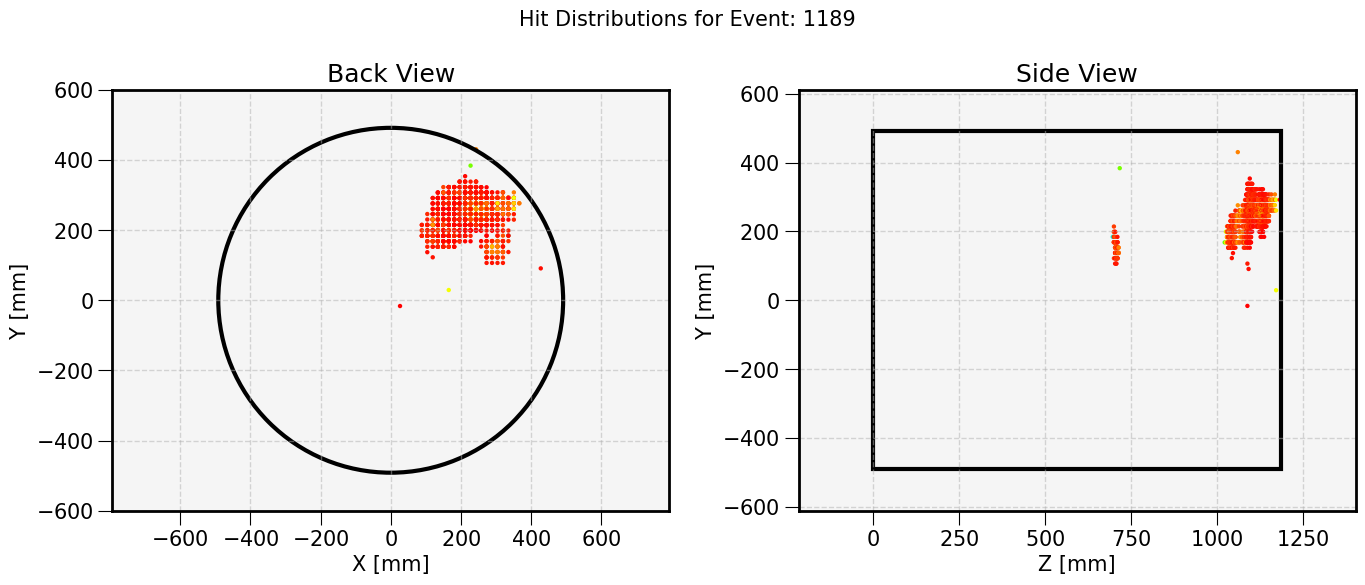

In [29]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(evts_higher_pe))

In [63]:
data_one_s1

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,S1e_corr
0,0,1.434202e+06,0,0,1,4,475.0,74.0,343.0,10000.0,...,776.487183,675.543762,5.600295,84.813773,163.882204,184.528461,1.093224,58.703473,68.342657,437.000344
1,0,1.434202e+06,0,1,1,4,475.0,74.0,343.0,10000.0,...,1001.489807,871.296082,8.095852,-367.944892,256.026258,448.255383,2.533672,70.833883,51.851566,396.012483
2,0,1.434202e+06,0,2,1,4,475.0,74.0,343.0,10000.0,...,1356.481445,1180.138794,7.598098,403.825193,-168.658599,437.630563,-0.395631,83.643768,39.218144,344.964517
3,0,1.434202e+06,0,3,1,4,475.0,74.0,343.0,10000.0,...,1452.494385,1263.670044,7.263157,409.009175,-133.712256,430.310903,-0.315965,55.692141,55.652847,333.342749
5,1,2.309077e+06,0,1,1,2,500.0,47.0,246.0,10025.0,...,1320.456055,1148.796753,13.256551,-296.718273,240.997858,382.258683,2.459450,85.894202,88.024988,250.688353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24351,19227,3.845585e+10,0,1,1,2,675.0,714.0,3059.0,10000.0,...,1359.489258,1182.755615,7.748323,313.410435,249.652909,400.690249,0.672645,115.530452,113.731679,3073.163777
24353,19228,3.845645e+10,0,1,1,2,600.0,20.0,96.0,10000.0,...,1358.485229,1181.882080,7.847504,286.836730,-285.741740,404.874859,-0.783486,64.480124,80.023316,96.479636
24355,19230,3.846104e+10,0,1,1,3,550.0,85.0,309.0,10000.0,...,1343.485352,1168.832153,12.943366,-228.055199,-312.810916,387.117350,-2.200755,75.956000,83.824213,312.243309
24356,19230,3.846104e+10,0,2,1,3,550.0,85.0,309.0,10000.0,...,1475.487915,1283.674438,6.877829,-194.371679,-299.320753,356.893910,-2.146733,117.615937,116.610313,297.896555


By now, it would not be important, 'cause we decide to not differenciate alphas/electrons in the MC of Bi @ cathode.

#### Is it important a NO-Polike cut?

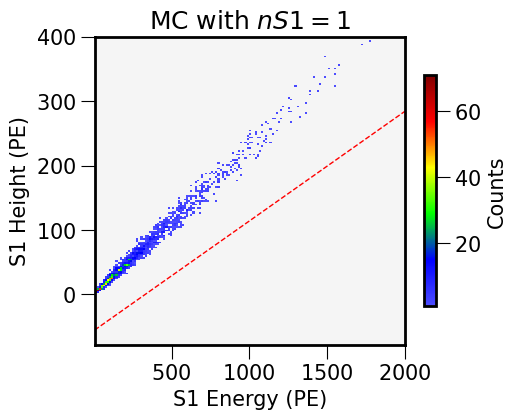

In [30]:
# Global
n_bins = 150
H1_max = 400; E1_max = 2e3

# Variables
H1 = data_one_s1['S1h']
E1 = data_one_s1['S1e']

# Binning
H1_bins = np.linspace(H1.min(), H1_max, n_bins)
E1_bins = np.linspace(E1.min(), E1_max, n_bins)

# 2D histogram: normalized by corrected DAQ data taking time
S1h_S1e_map, ex, ey = np.histogram2d(E1, H1, bins=[E1_bins, H1_bins])
S1h_S1e_map         = np.ma.masked_where(S1h_S1e_map==0, S1h_S1e_map)     # Zero values masked

# Plotting
plt.figure(figsize=(5, 4))
plt.pcolormesh(ex, ey, S1h_S1e_map.T, cmap=pt.custom_hsv, shading='auto')
plt.plot(E1_bins, ff.linear_func(E1_bins, M_NOPOLIKE, B_NOPOLIKE), c='red', ls='--', lw=1)        # Limit line

# Styling
cbar = plt.colorbar(label='Counts', shrink=0.75)
# cbar.formatter.set_powerlimits((-3, -3))
plt.xlabel('S1 Energy (PE)')
plt.ylabel('S1 Height (PE)')
plt.title(r'MC with $nS1 = 1$')
plt.gca().set_facecolor("whitesmoke")
plt.show()

Nope, it is completely unnecesary.

### Execution

In [31]:
print("After S1 signal cuts:")

# ----- Counters for Efficiencies ----- #
evt_prior = test_soph['event'].nunique()
nS1_0_evt_ids = test_doro.loc[test_doro['nS1'] == 0, 'event'].unique();   print(f"    nS1 = 0: {len(nS1_0_evt_ids)} events ({len(nS1_0_evt_ids)/evt_prior:.2%})")
nS1_1_evt_ids = test_doro.loc[test_doro['nS1'] == 1, 'event'].unique();   print(f"    nS1 = 1: {len(nS1_1_evt_ids)} events ({len(nS1_1_evt_ids)/evt_prior:.2%})")

# ----- S1 Signal ----- #
test_doro = test_doro[(test_doro['nS1'] == 0) | (test_doro['nS1'] == 1)].copy()

# ----- S1e Correction ----- #
test_doro = crudo.correct_S1e(test_doro, CV_FIT, DT_STOP, output_column='S1e_corr')    # I'll work with this corrected S1 energy
# Check if the correction was applied
if 'S1e_corr' not in test_doro.columns:
    print(f"Error: S1e correction not applied! Skipping...")

# Update dataframes
good_evts_02 = test_doro['event'].unique()
test_soph = test_soph[test_soph['event'].isin(good_evts_02)].copy()

print(f"{len(good_evts_02)} events ({len(good_evts_02)/evt_prior:.2%})")

After S1 signal cuts:
    nS1 = 0: 352 events (12.66%)
    nS1 = 1: 2423 events (87.16%)
2775 events (99.82%)


## Topology

In [32]:
print(f"Until now, we have: {test_soph.event.nunique()} remaining events.")
test_soph

Until now, we have: 2775 remaining events.


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,0,1.434202e+06,0,84.813773,163.882205,1,-126.975,-247.675,0.0,0.0,660.045456,15.594203,72.000000,-1.0,0.000183,-1,-1.0
1,0,1.434202e+06,0,84.813773,163.882205,1,88.725,152.625,0.0,0.0,666.764139,8.463768,1789.276581,-1.0,0.004442,-1,-1.0
2,0,1.434202e+06,0,84.813773,163.882205,1,88.725,168.175,0.0,0.0,666.764139,7.884058,1666.723419,-1.0,0.004131,-1,-1.0
3,0,1.434202e+06,0,84.813773,163.882205,1,57.625,168.175,0.0,0.0,670.186176,6.260870,357.981558,-1.0,0.000885,-1,-1.0
4,0,1.434202e+06,0,84.813773,163.882205,1,57.625,199.275,0.0,0.0,670.186176,7.014493,401.071921,-1.0,0.000996,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764461,3830,7.661317e+09,0,-254.521696,114.991174,1,-265.925,122.025,0.0,0.0,1184.891606,6.724638,656.792542,-1.0,0.001700,-1,-1.0
3764462,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,106.475,0.0,0.0,1184.891606,5.449275,532.228466,-1.0,0.001370,-1,-1.0
3764463,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,122.025,0.0,0.0,1184.891606,7.246377,707.750620,-1.0,0.001827,-1,-1.0
3764464,3830,7.661317e+09,0,-254.521696,114.991174,1,-235.825,106.975,0.0,0.0,1184.891606,6.086957,594.510504,-1.0,0.001523,-1,-1.0


In [41]:
cluster_tagger = crudo.hits_clusterizer(eps=3, min_samples=5)

# Dataframe with clustered hits
hits_clustered_df = cluster_tagger(test_soph)

In [50]:
hits_clustered_df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster
0,0,1.434202e+06,0,84.813773,163.882205,1,-126.975,-247.675,0.0,0.0,660.045456,15.594203,72.000000,-1.0,0.000183,-1,-1.0,-1
1,0,1.434202e+06,0,84.813773,163.882205,1,88.725,152.625,0.0,0.0,666.764139,8.463768,1789.276581,-1.0,0.004442,-1,-1.0,0
2,0,1.434202e+06,0,84.813773,163.882205,1,88.725,168.175,0.0,0.0,666.764139,7.884058,1666.723419,-1.0,0.004131,-1,-1.0,0
3,0,1.434202e+06,0,84.813773,163.882205,1,57.625,168.175,0.0,0.0,670.186176,6.260870,357.981558,-1.0,0.000885,-1,-1.0,0
4,0,1.434202e+06,0,84.813773,163.882205,1,57.625,199.275,0.0,0.0,670.186176,7.014493,401.071921,-1.0,0.000996,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764461,3830,7.661317e+09,0,-254.521696,114.991174,1,-265.925,122.025,0.0,0.0,1184.891606,6.724638,656.792542,-1.0,0.001700,-1,-1.0,0
3764462,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,106.475,0.0,0.0,1184.891606,5.449275,532.228466,-1.0,0.001370,-1,-1.0,0
3764463,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,122.025,0.0,0.0,1184.891606,7.246377,707.750620,-1.0,0.001827,-1,-1.0,0
3764464,3830,7.661317e+09,0,-254.521696,114.991174,1,-235.825,106.975,0.0,0.0,1184.891606,6.086957,594.510504,-1.0,0.001523,-1,-1.0,0


In [35]:
events_with_secondary_tracks = hits_clustered_df.loc[hits_clustered_df['cluster'] > 0, 'event'].unique()
print(f"Events with secondary tracks: {len(events_with_secondary_tracks)}")

Events with secondary tracks: 1084


Check some events to see the result!

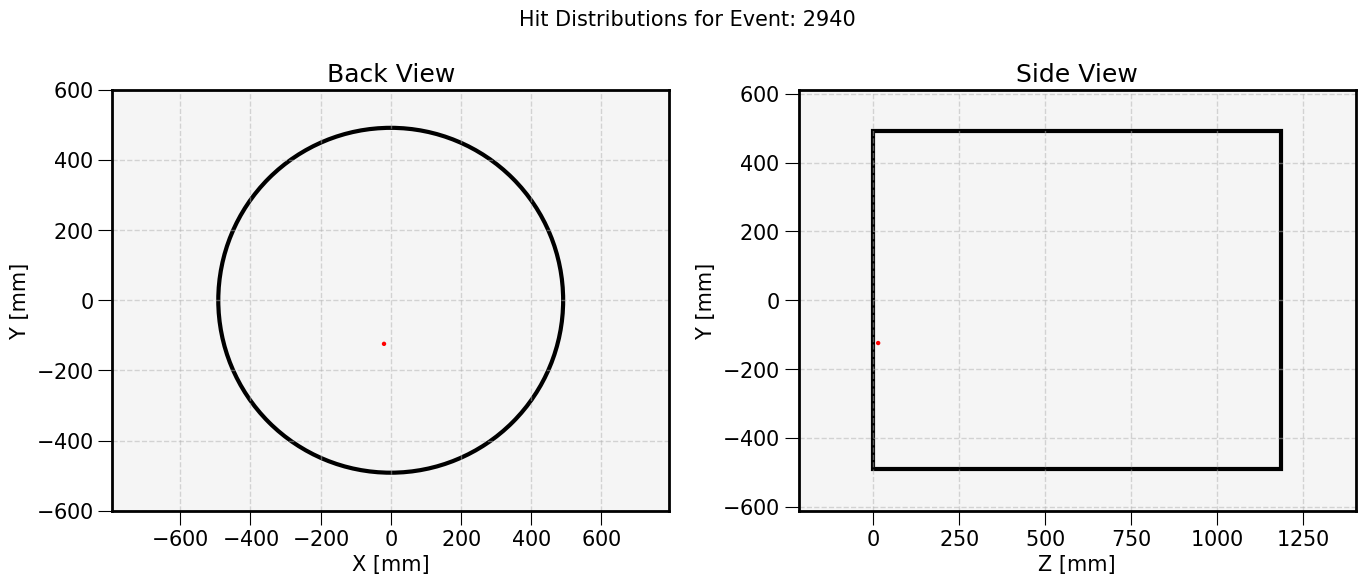

In [72]:
# event_to_try = np.random.choice(events_with_secondary_tracks)
event_to_try = 2940
pt.event_display(hits_clustered_df, variable='Ec', event=event_to_try)

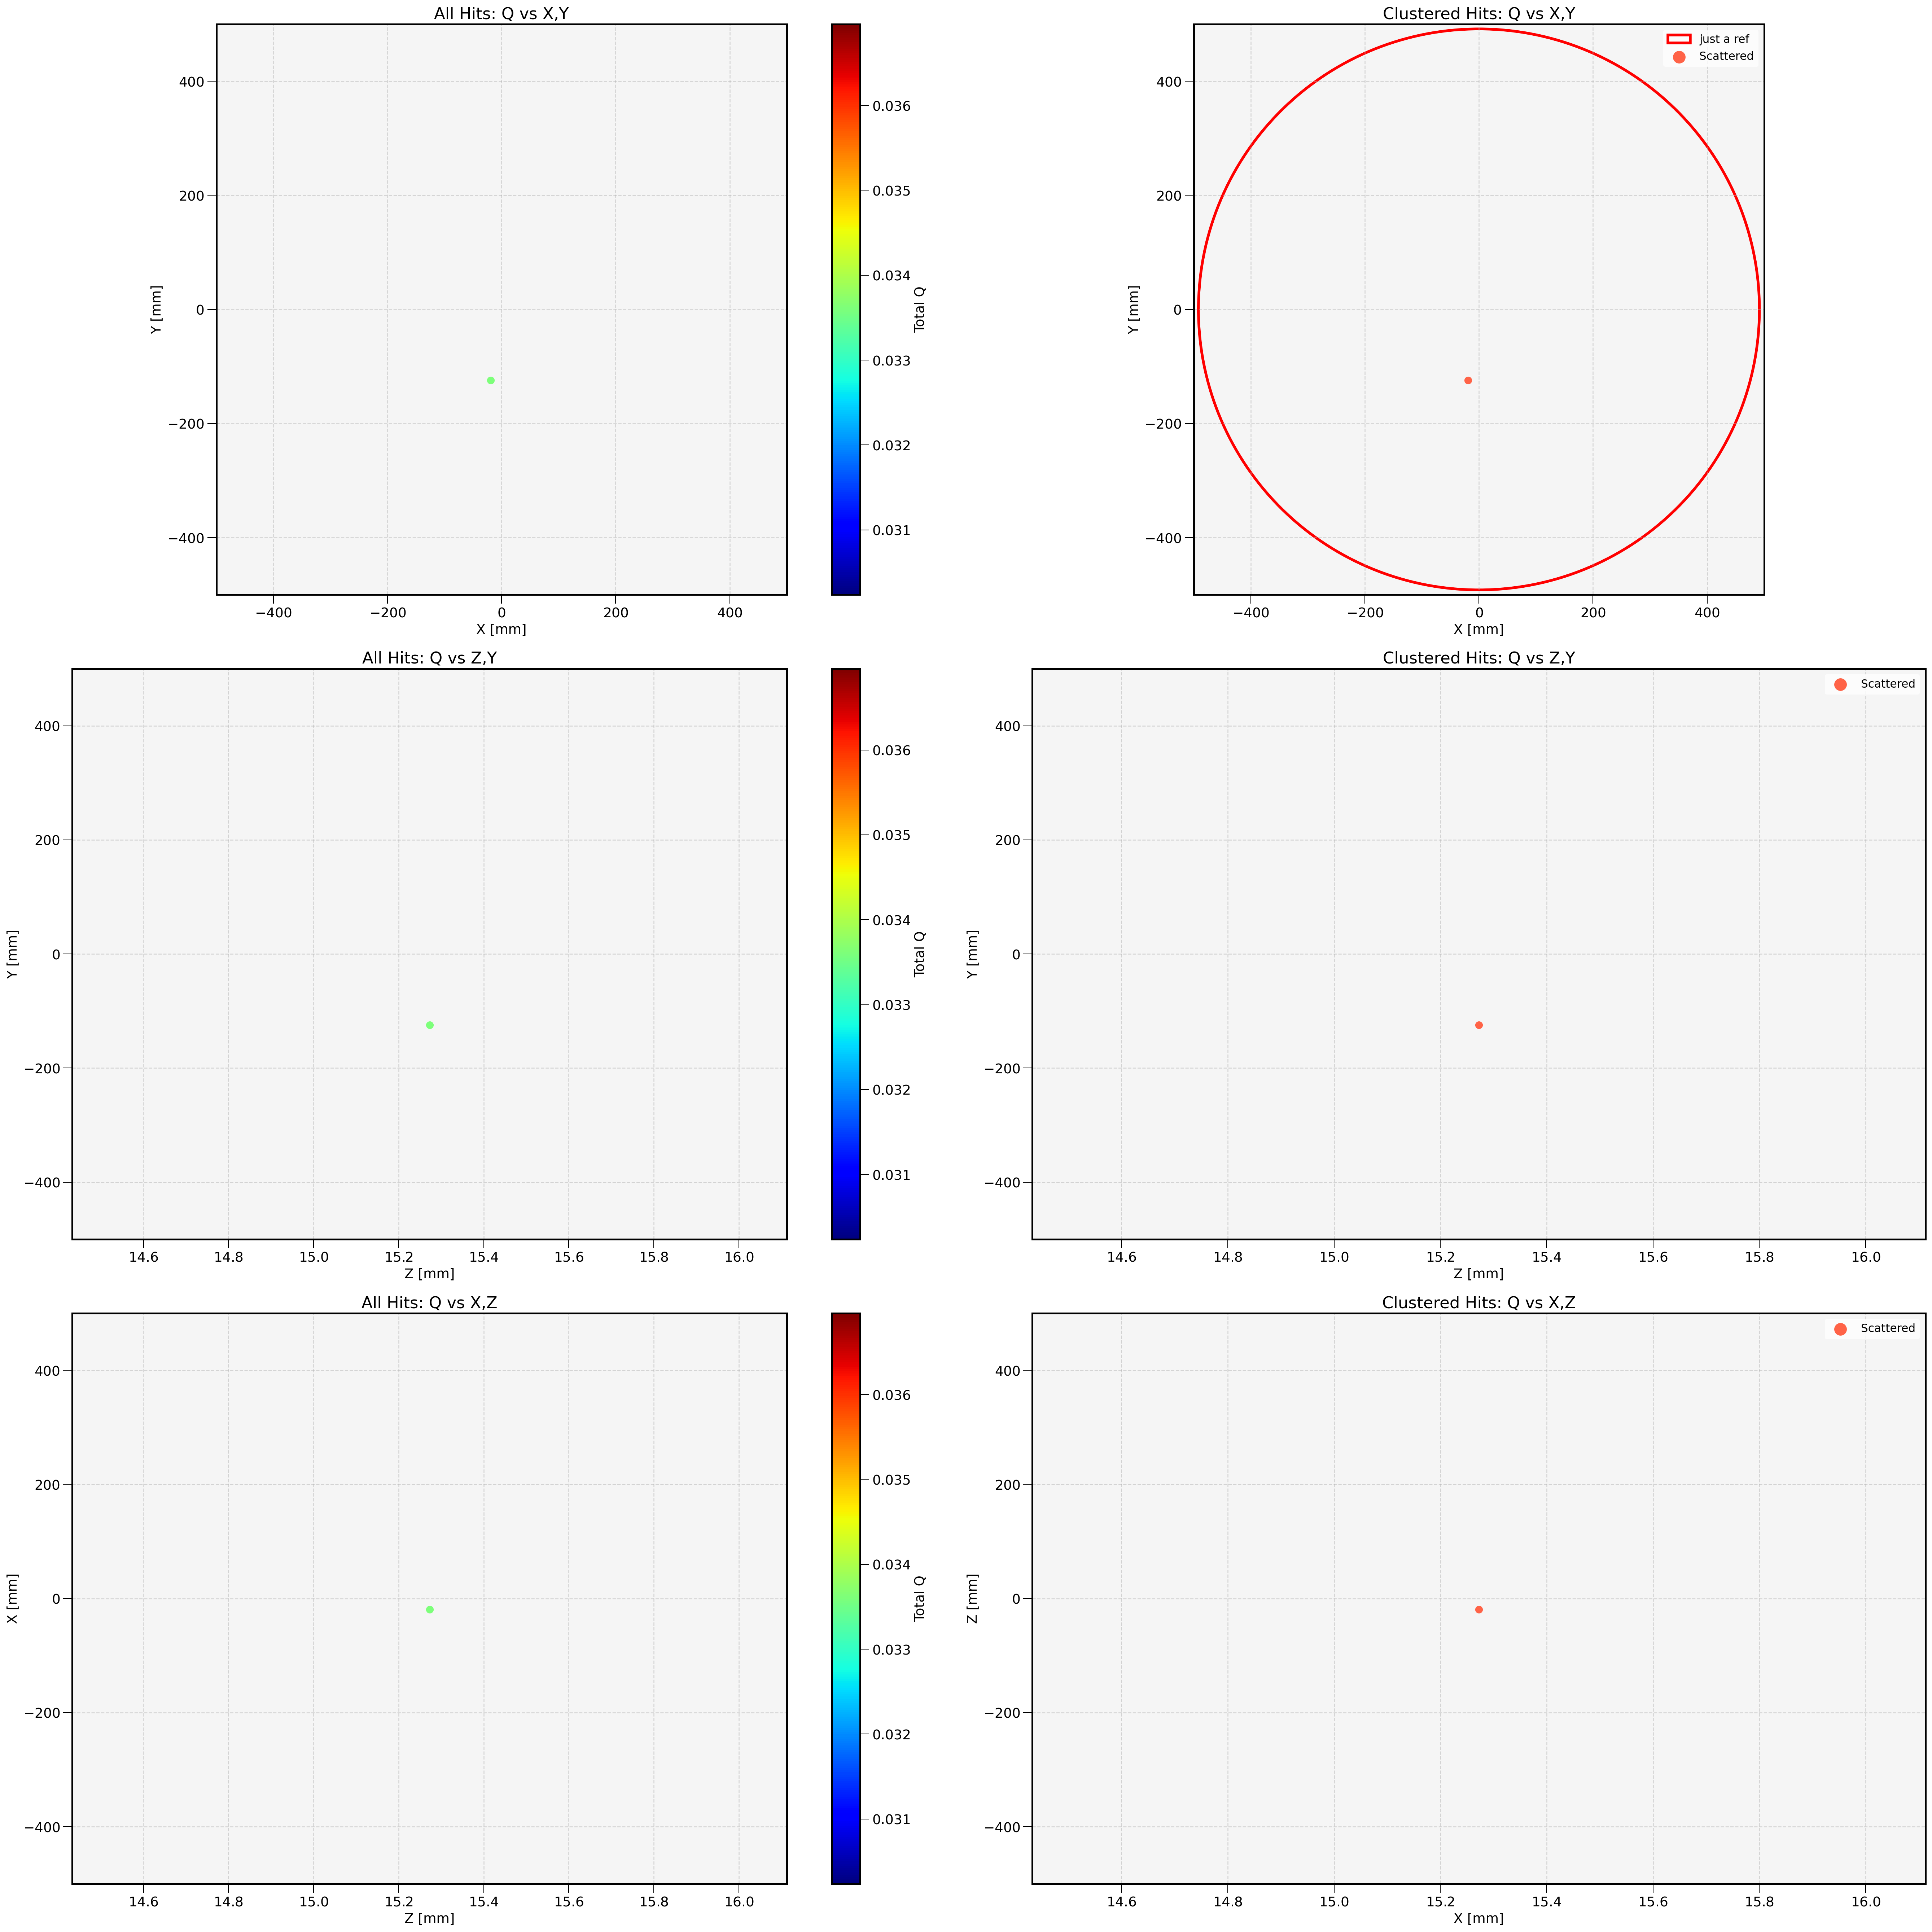

In [73]:
event_clustered = hits_clustered_df[hits_clustered_df['event'] == event_to_try]
pt.display_event_cluster(event_clustered, energy_column='Ec')

In [44]:
# If after remove tags -1 (noise) and 0 (main cluster) there are still clusters tag, then the event has NOT a single track
topology_info = hits_clustered_df.groupby(['event'])['cluster'].apply(
                    lambda clusters: 'yes' if not set(clusters.unique()) - {-1, 0} else 'no'
                )
# Let's rename the series for clarity
topology_info = topology_info.rename('single_track')
topology_info

event
0        no
1       yes
4        no
5       yes
6       yes
       ... 
3826    yes
3827    yes
3828     no
3829     no
3830    yes
Name: single_track, Length: 2775, dtype: object

In [49]:
test_soph = hits_clustered_df.copy()

## Data @ Event/Peak-level

### From Dorothea

In [51]:
test_doro

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,S1e_corr
0,0,1.434202e+06,0,0,1,4,475.0,74.0,343.0,10000.0,...,776.487183,675.543762,5.600295,84.813773,163.882204,184.528461,1.093224,58.703473,68.342657,437.000344
1,0,1.434202e+06,0,1,1,4,475.0,74.0,343.0,10000.0,...,1001.489807,871.296082,8.095852,-367.944892,256.026258,448.255383,2.533672,70.833883,51.851566,396.012483
2,0,1.434202e+06,0,2,1,4,475.0,74.0,343.0,10000.0,...,1356.481445,1180.138794,7.598098,403.825193,-168.658599,437.630563,-0.395631,83.643768,39.218144,344.964517
3,0,1.434202e+06,0,3,1,4,475.0,74.0,343.0,10000.0,...,1452.494385,1263.670044,7.263157,409.009175,-133.712256,430.310903,-0.315965,55.692141,55.652847,333.342749
5,1,2.309077e+06,0,1,1,2,500.0,47.0,246.0,10025.0,...,1320.456055,1148.796753,13.256551,-296.718273,240.997858,382.258683,2.459450,85.894202,88.024988,250.688353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4963,3828,7.656743e+09,0,0,1,2,275.0,8.0,32.0,10050.0,...,1363.448975,1186.200562,7.575108,203.712976,-44.183359,208.449385,-0.213582,83.381151,41.767572,32.102059
4964,3828,7.656743e+09,0,1,1,2,275.0,8.0,32.0,10050.0,...,1489.434448,1295.807861,4.513122,204.359104,-37.493816,207.770137,-0.181452,68.874820,58.059762,30.701090
4965,3829,7.658624e+09,0,0,1,2,425.0,46.0,208.0,10000.0,...,1348.481201,1173.178589,8.802026,-1.349733,55.817951,55.834267,1.594973,83.860574,81.497269,209.800794
4966,3829,7.658624e+09,0,1,1,2,425.0,46.0,208.0,10000.0,...,1489.505127,1295.869385,2.946344,58.771596,45.178307,74.129481,0.655368,122.602325,49.373291,199.552201


In [56]:
# ----- Dorothea Aggregation ----- #
doro_agg_dict = {
                    'time': ('time', 'mean'),
                    'nS1': ('nS1', 'max'),
                    'nS2': ('nS2', 'max'),
                    'S1e': ('S1e', 'max'),
                    'S1e_corr': ('S1e_corr', 'max'),
                }
doro_agg_df = test_doro.groupby('event', as_index=False).agg(**doro_agg_dict)
doro_agg_df

,event,time,nS1,nS2,S1e,S1e_corr
0,0,1.434202e+06,1,4,343.0,437.000344
1,1,2.309077e+06,1,2,246.0,250.688353
2,4,9.143824e+06,1,2,279.0,280.393556
3,5,1.199260e+07,1,2,162.0,163.164429
4,6,1.368604e+07,1,2,128.0,135.265437
...,...,...,...,...,...,...
2770,3826,7.652959e+09,1,1,272.0,273.856537
2771,3827,7.655161e+09,1,1,53.0,52.692580
2772,3828,7.656743e+09,1,2,32.0,32.102059
2773,3829,7.658624e+09,1,2,208.0,209.800794


### From Sophronia

In [62]:
test_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster
0,0,1.434202e+06,0,84.813773,163.882205,1,-126.975,-247.675,0.0,0.0,660.045456,15.594203,72.000000,-1.0,0.000183,-1,-1.0,-1
1,0,1.434202e+06,0,84.813773,163.882205,1,88.725,152.625,0.0,0.0,666.764139,8.463768,1789.276581,-1.0,0.004442,-1,-1.0,0
2,0,1.434202e+06,0,84.813773,163.882205,1,88.725,168.175,0.0,0.0,666.764139,7.884058,1666.723419,-1.0,0.004131,-1,-1.0,0
3,0,1.434202e+06,0,84.813773,163.882205,1,57.625,168.175,0.0,0.0,670.186176,6.260870,357.981558,-1.0,0.000885,-1,-1.0,0
4,0,1.434202e+06,0,84.813773,163.882205,1,57.625,199.275,0.0,0.0,670.186176,7.014493,401.071921,-1.0,0.000996,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764461,3830,7.661317e+09,0,-254.521696,114.991174,1,-265.925,122.025,0.0,0.0,1184.891606,6.724638,656.792542,-1.0,0.001700,-1,-1.0,0
3764462,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,106.475,0.0,0.0,1184.891606,5.449275,532.228466,-1.0,0.001370,-1,-1.0,0
3764463,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,122.025,0.0,0.0,1184.891606,7.246377,707.750620,-1.0,0.001827,-1,-1.0,0
3764464,3830,7.661317e+09,0,-254.521696,114.991174,1,-235.825,106.975,0.0,0.0,1184.891606,6.086957,594.510504,-1.0,0.001523,-1,-1.0,0


In [63]:
# ----- Sophronia Aggregation ----- #
soph_agg_dict = {
                    'X_bary': ('X', lambda x: bf.weighted_avg(x, test_soph.loc[x.index, 'Ec'])),
                    'Y_bary': ('Y', lambda y: bf.weighted_avg(y, test_soph.loc[y.index, 'Ec'])),
                    'Z_bary': ('Z', lambda z: bf.weighted_avg(z, test_soph.loc[z.index, 'Ec'])),
                    'Z_min': ('Z', 'min'),
                    'Z_max': ('Z', 'max'),
                    'R_max': ('X', lambda g: bf.R_max_func(test_soph.loc[g.index])),
                    'E_evt_mev': ('Ec', 'sum'),
                    'n_cluster': ('cluster', 'max')
                }

### Aggregate

In [64]:
# Perform aggregation
df_event = test_soph.groupby('event', as_index=False).agg(**soph_agg_dict)
df_event

,event,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_mev,n_cluster
0,0,169.343029,4.040181,1048.267768,660.045456,1275.048836,511.922832,1.056133,3
1,1,-311.193402,256.576148,1151.741938,1133.088217,1188.223489,528.117758,0.488223,0
2,4,-389.348785,-251.846303,1220.717102,1156.417702,1294.694959,539.255604,0.936507,1
3,5,-427.131233,139.167993,1177.332623,1164.223125,1195.189253,506.334036,0.356754,0
4,6,-273.631751,-316.367478,1064.283783,1052.100026,1075.893765,473.768858,0.247048,0
...,...,...,...,...,...,...,...,...,...
2770,3826,-279.663650,374.313384,1172.976130,1149.475103,1190.832510,507.585595,0.498026,0
2771,3827,-100.481861,-177.575017,1197.528292,1175.482448,1220.239271,492.398285,0.453498,0
2772,3828,213.687952,-39.303139,1232.278112,1174.700100,1295.807906,275.247491,0.290745,1
2773,3829,1.053989,60.851211,1179.999670,1157.381228,1295.469368,128.958487,0.398055,1


In [71]:
df_event = df_event.merge(doro_agg_df, on='event', how='left')

## Tagging by Detector Region

# Selection

Ok, so we start from this dataframes...

In [74]:
df_event

,event,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_mev,n_cluster,time,nS1,nS2,S1e,S1e_corr
0,0,169.343029,4.040181,1048.267768,660.045456,1275.048836,511.922832,1.056133,3,1.434202e+06,1,4,343.0,437.000344
1,1,-311.193402,256.576148,1151.741938,1133.088217,1188.223489,528.117758,0.488223,0,2.309077e+06,1,2,246.0,250.688353
2,4,-389.348785,-251.846303,1220.717102,1156.417702,1294.694959,539.255604,0.936507,1,9.143824e+06,1,2,279.0,280.393556
3,5,-427.131233,139.167993,1177.332623,1164.223125,1195.189253,506.334036,0.356754,0,1.199260e+07,1,2,162.0,163.164429
4,6,-273.631751,-316.367478,1064.283783,1052.100026,1075.893765,473.768858,0.247048,0,1.368604e+07,1,2,128.0,135.265437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,3826,-279.663650,374.313384,1172.976130,1149.475103,1190.832510,507.585595,0.498026,0,7.652959e+09,1,1,272.0,273.856537
2771,3827,-100.481861,-177.575017,1197.528292,1175.482448,1220.239271,492.398285,0.453498,0,7.655161e+09,1,1,53.0,52.692580
2772,3828,213.687952,-39.303139,1232.278112,1174.700100,1295.807906,275.247491,0.290745,1,7.656743e+09,1,2,32.0,32.102059
2773,3829,1.053989,60.851211,1179.999670,1157.381228,1295.469368,128.958487,0.398055,1,7.658624e+09,1,2,208.0,209.800794


In [76]:
print(f"Events according hits dataframe: {test_soph.event.nunique()}")
test_soph

Events according hits dataframe: 2775


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster
0,0,1.434202e+06,0,84.813773,163.882205,1,-126.975,-247.675,0.0,0.0,660.045456,15.594203,72.000000,-1.0,0.000183,-1,-1.0,-1
1,0,1.434202e+06,0,84.813773,163.882205,1,88.725,152.625,0.0,0.0,666.764139,8.463768,1789.276581,-1.0,0.004442,-1,-1.0,0
2,0,1.434202e+06,0,84.813773,163.882205,1,88.725,168.175,0.0,0.0,666.764139,7.884058,1666.723419,-1.0,0.004131,-1,-1.0,0
3,0,1.434202e+06,0,84.813773,163.882205,1,57.625,168.175,0.0,0.0,670.186176,6.260870,357.981558,-1.0,0.000885,-1,-1.0,0
4,0,1.434202e+06,0,84.813773,163.882205,1,57.625,199.275,0.0,0.0,670.186176,7.014493,401.071921,-1.0,0.000996,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764461,3830,7.661317e+09,0,-254.521696,114.991174,1,-265.925,122.025,0.0,0.0,1184.891606,6.724638,656.792542,-1.0,0.001700,-1,-1.0,0
3764462,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,106.475,0.0,0.0,1184.891606,5.449275,532.228466,-1.0,0.001370,-1,-1.0,0
3764463,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,122.025,0.0,0.0,1184.891606,7.246377,707.750620,-1.0,0.001827,-1,-1.0,0
3764464,3830,7.661317e+09,0,-254.521696,114.991174,1,-235.825,106.975,0.0,0.0,1184.891606,6.086957,594.510504,-1.0,0.001523,-1,-1.0,0


## Trigger2 Efficiency: or energy window

In [ ]:
# ----- Trigger 2 Efficiency Cut ----- #
good_trg2_ids = df_event.loc[df_event['E_evt_mev'] >= TRG2_THRESHOLD, 'event'].unique()
print(f"After trigger 2 efficiency ({TRG2_THRESHOLD} MeV): {len(good_trg2_ids)} events ({len(good_trg2_ids)/len(positive_Ec_ids):.2%})")

# Update dataframes
test_doro, test_soph = bf.apply_cut_and_update(test_doro, test_soph, event_ids=good_trg2_ids)
print(f"\nDorothea events = {test_doro.event.nunique()}\nSophronia events = {test_soph.event.nunique()}")

After trigger 2 efficiency (0.5 MeV): 17751 events (64.00%)

Dorothea events = 17751
Sophronia events = 17751


## $S2$ Signal

#### How does it behave the $S2$ energy?

In [ ]:
# ----- nS2 = 1 ----- #
data_S2 = test_doro[test_doro['nS2'] == 1].copy()

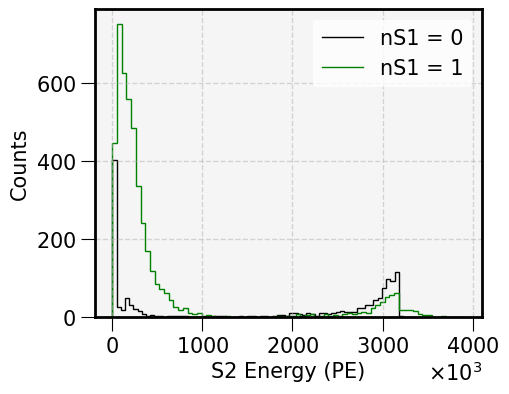

In [ ]:
# Global
n_bins = 75
E2_max = 2000e3

plt.figure(figsize=(5, 4))

for i, label in enumerate(['nS1 = 0', 'nS1 = 1']):
    
    if label == 'nS1 = 0':
        data = data_S2[data_S2['nS1'] == 0].copy()
        E2 = data['S2e']
    else:
        data = data_S2[data_S2['nS1'] == 1].copy()
        E2 = data['S2e']

    # Histogram
    E2_counts, E2_edges = np.histogram(E2, bins=n_bins)

    # Plotting
    plt.stairs(E2_counts, E2_edges, label=label, 
               fill=False, lw=1.0, ec=pt.hist_colors[4*i % len(pt.hist_colors)])

# Styling
plt.xlabel('S2 Energy (PE)')
# plt.xlim(0, E2_max)
plt.ylabel('Counts')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

#### __THESE COMMENTS ARE VALID JUST FOR CATHODE MC FILES__

We know that alpha population is around $1000\times10^{3}\,\text{pe}$.
<br>
The $nS2 = 1$ cut remove almost all the aplha contribution (BiPo coincidence!).
<br>
In any case, let's check that population of events around $3000\times10^{3}\,\text{pe}$.

In [ ]:
pop_3000_ids = data_S2.loc[data_S2['S2e'] >= 1500e3, 'event'].unique()
print(len(pop_3000_ids))

1343


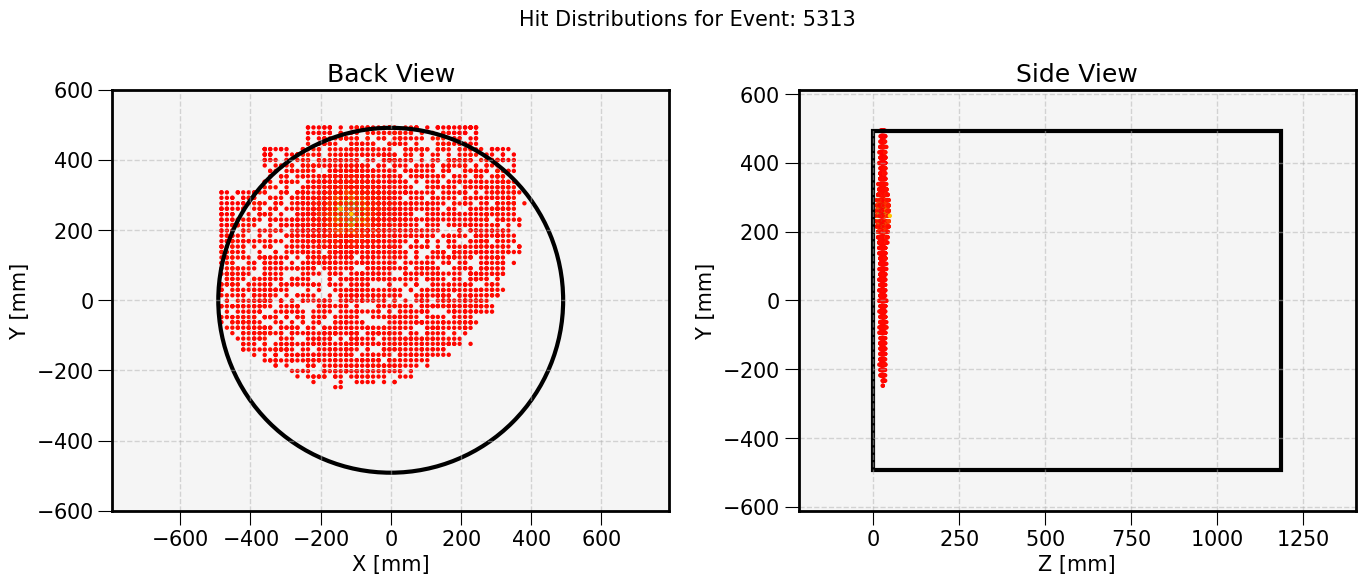

In [ ]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(pop_3000_ids))

This population seems to be alphas but with so many hits! __Why?__

In [ ]:
pop_std_ids = data_S2.loc[data_S2['S2e'] < 1500e3, 'event'].unique()
print(len(pop_std_ids))

926


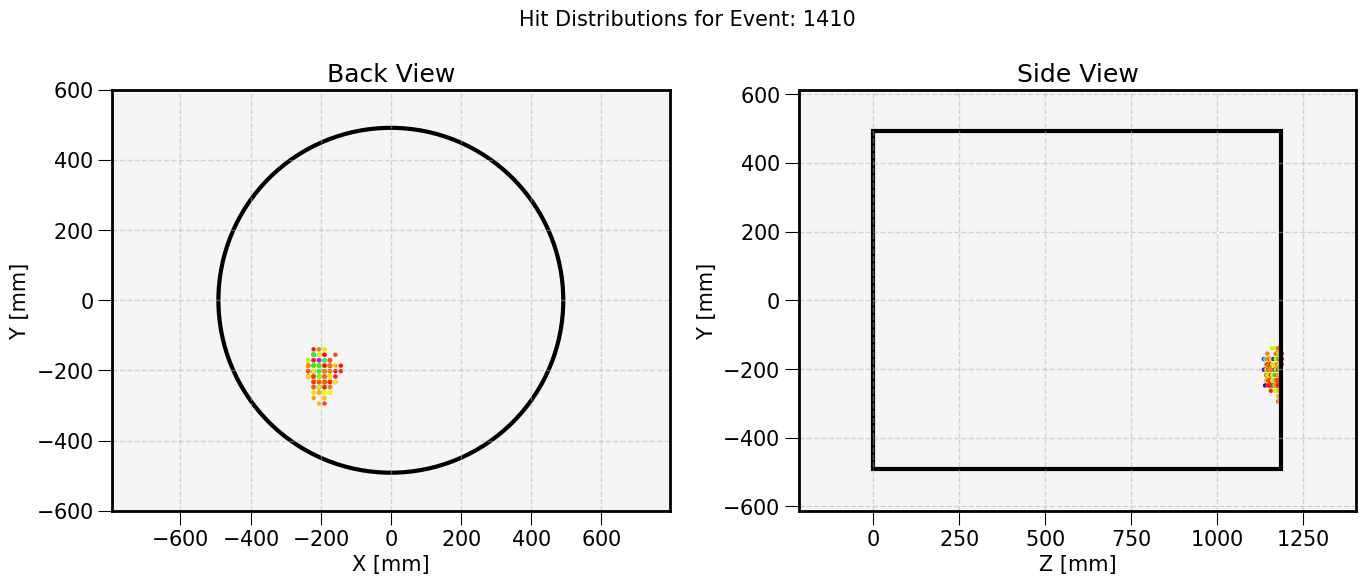

In [ ]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(pop_std_ids))

Here I notice more events "well-reconstructed", but we still need to distinguish between alphas and electrons.
<br>
First, we apply the $nS2 = 1$ cut.
<br>
__Notice the low efficieny, we are killing the BiPo coincidence!__

### Execution

In [ ]:
# Event counter
evt_prior = test_soph['event'].nunique()

# ----- S2 Signal ----- #
test_doro = test_doro[test_doro['nS2'] == 1].copy()

# Update dataframes
good_evt_03 = test_doro['event'].unique()
test_soph = test_soph[test_soph['event'].isin(good_evt_03)].copy()

print(f"After S2 signal cut: {len(good_evt_03)} events ({len(good_evt_03)/evt_prior:.2%})")

After S2 signal cut: 4684 events (62.54%)


## $\alpha$ and $e$ Populations

__NOTE:__ Just the cathode MC files include $\alpha$ population.

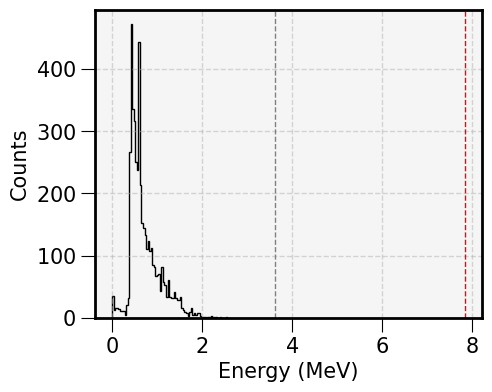

In [ ]:
# Global
n_bins = 75

# Variables
E = test_soph.groupby('event')['Ec'].sum()

# Histogram
E_counts, E_edges = np.histogram(E, bins=n_bins)

# Plotting
plt.figure(figsize=(5, 4))
plt.stairs(E_counts, E_edges,
           fill=False, lw=1.0, ec='black')
    
# 214Po peak as reference!
x_Po = 7.83
plt.axvline(x=x_Po, color='red', ls='--', lw=1)
# plt.text(0.98*x_Po, 300, f'{x_Po} MeV', c='red', ha='right', va='bottom')

# Energy threshold
x_flag = ENERGY_THRESHOLD_MEV
plt.axvline(x=x_flag, color='gray', ls='--', lw=1)
# plt.text(0.98*x_flag, 300, f'{x_flag:.2f} MeV', c='gray', ha='right', va='bottom')

# Styling
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

As alphas, we expect to have them around $7.83\,\text{MeV}$ (the Q value of $^{214}\text{Po}$).
<br>
I will use the same energy threshold to separate alphas and electrons (gray line).

In [ ]:
# Event counter
evt_prior = test_soph['event'].nunique()

# Variables
evt_energy = test_soph.groupby('event')['Ec'].sum()

# Event IDs for alphas and electrons
elec_ids  = evt_energy[evt_energy <= ENERGY_THRESHOLD_MEV].index
alpha_ids = evt_energy[evt_energy >  ENERGY_THRESHOLD_MEV].index

# Update dataframes
test_doro = test_doro[test_doro['event'].isin(elec_ids)].copy()
test_soph = test_soph[test_soph['event'].isin(elec_ids)].copy() 
print(f"Electron candidates: {len(elec_ids)} events ({len(elec_ids)/evt_prior:.2%}) ")

Electron candidates: 4684 events (100.00%) 


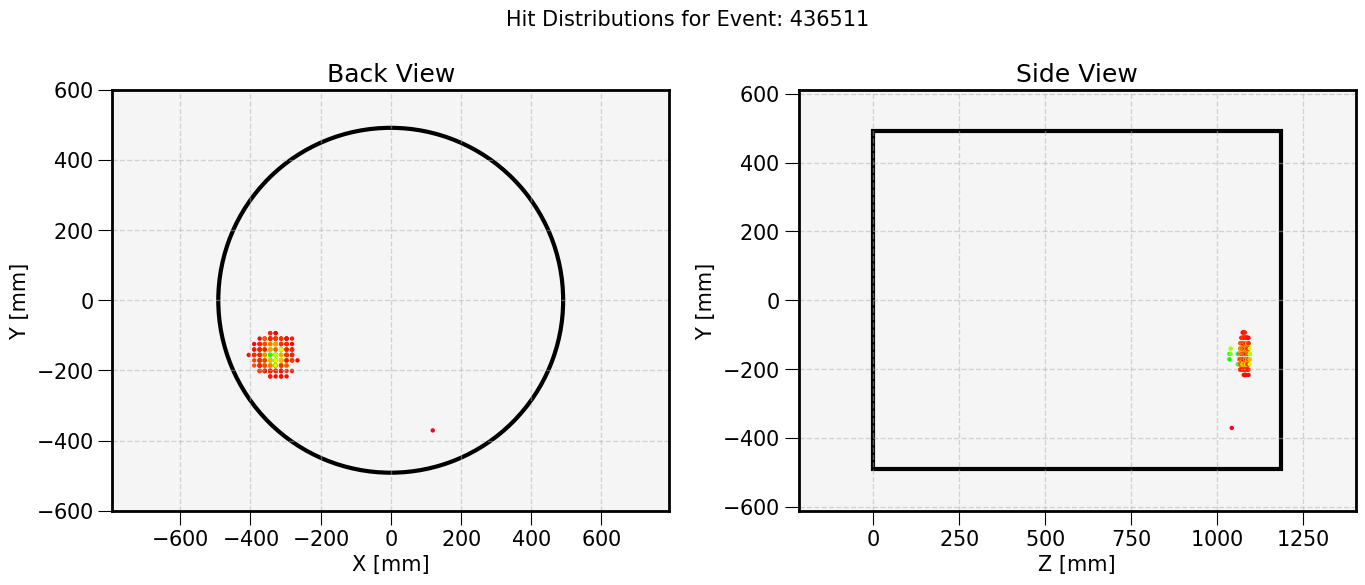

In [ ]:
pt.event_display(test_soph, variable='Ec')

Max. Energy: 2.5634 MeV


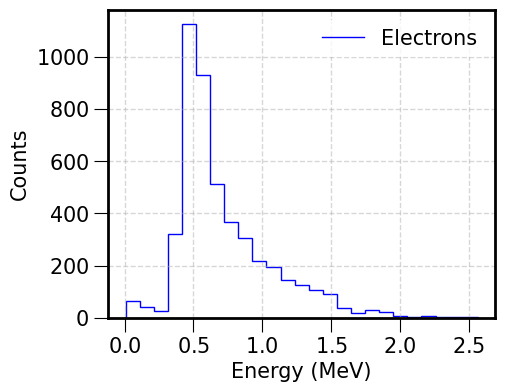

In [ ]:
E_electron_evt = test_soph.groupby('event')['Ec'].sum()
print(f'Max. Energy: {E_electron_evt.max():.4f} MeV')

# Binning
E_electron, e_elec = np.histogram(E_electron_evt, bins=25)

plt.figure(figsize=(5, 4))
plt.stairs(E_electron, e_elec, fill=False, ec='blue', lw=1.0, label='Electrons')
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.show()

# Analysis

In [4]:
# ----- INPUT FILEPATHS ----- #
ALL_PATH  = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/processed_MC_background_All_01122025.h5'
CATH_PATH = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/processed_MC_background_Cathode_01122025.h5'

# ----- DATAFRAMES ----- #
ALL_EVTS_DF  = pd.read_hdf(ALL_PATH, key='Events')
CATH_EVTS_DF = pd.read_hdf(CATH_PATH, key='Events')
# CATH_HITS_DF = pd.read_hdf(CATH_PATH, key='Hits')

# ----- SIMULATED EXPOSURE TIME ----- #
RUN_TIME_ALL  = 315360000    # 10 years in [s]
scale_factor = 1.17 / 0.82
RUN_TIME_CATH = 315360 * scale_factor       # 0.01 year in [s]

# ----- GENERATED EVENTS ----- #
# You can find these numbers in Bi_MC_Effs.txt
GEN_EVTS_ALL  = 2918945850
GEN_EVTS_CATH = 385000

# ROI definition
ROI_MIN = 2.4; ROI_MAX = 2.5    # in [MeV]

Now, we are solely interested in __fiducial events__!

In [5]:
all_fidu_evts_df  = ALL_EVTS_DF[ALL_EVTS_DF['region'] == 'fiducial'].copy()
cath_fidu_evts_df = CATH_EVTS_DF[CATH_EVTS_DF['region'] == 'fiducial'].copy()

In [6]:
print('From 214Bi-MC @ all volumes:')
# Inclusive region
incl_all_CV, incl_all_var = scipy.stats.binom.stats(n=GEN_EVTS_ALL, p=ALL_EVTS_DF['global_event'].nunique()/GEN_EVTS_ALL, moments='mv')
print(f'\n  → Inclusive events: {incl_all_CV:.0f} ± {np.sqrt(incl_all_var):.0f}')
ALL_RATE_INCL_CV  = incl_all_CV / RUN_TIME_ALL                # in [Hz]
ALL_RATE_INCL_ERR = np.sqrt(incl_all_var) / RUN_TIME_ALL      # in [Hz]
print(f'  → Inclusive rate: ({ALL_RATE_INCL_CV*1e3:.4f} ± {ALL_RATE_INCL_ERR*1e3:.4f}) mHz')
# Fiducial region
fidu_all_CV, fidu_all_var = scipy.stats.binom.stats(n=GEN_EVTS_ALL, p=all_fidu_evts_df['global_event'].nunique()/GEN_EVTS_ALL, moments='mv')
print(f'\n  → Fiducial events: {fidu_all_CV:.0f} ± {np.sqrt(fidu_all_var):.0f}')
ALL_RATE_FIDU_CV  = fidu_all_CV / RUN_TIME_ALL                # in [Hz]
ALL_RATE_FIDU_ERR = np.sqrt(fidu_all_var) / RUN_TIME_ALL      # in [Hz]
print(f'  → Fiducial rate: ({ALL_RATE_FIDU_CV*1e3:.4f} ± {ALL_RATE_FIDU_ERR*1e3:.4f}) mHz')

# ---------- #

print('\nFrom 214Bi-MC @ cathode:')
# Inclusive region
incl_cath_CV, incl_cath_var = scipy.stats.binom.stats(n=GEN_EVTS_CATH, p=CATH_EVTS_DF['global_event'].nunique()/GEN_EVTS_CATH, moments='mv')
print(f'\n  → Inclusive events: {incl_cath_CV:.0f} ± {np.sqrt(incl_cath_var):.0f}')
CATH_RATE_INCL_CV  = incl_cath_CV / RUN_TIME_CATH                # in [Hz]
CATH_RATE_INCL_ERR = np.sqrt(incl_cath_var) / RUN_TIME_CATH      # in [Hz]
print(f'  → Inclusive rate: ({CATH_RATE_INCL_CV*1e3:.4f} ± {CATH_RATE_INCL_ERR*1e3:.4f}) mHz')
# Fiducial region
fidu_cath_CV, fidu_cath_var = scipy.stats.binom.stats(n=GEN_EVTS_CATH, p=cath_fidu_evts_df['global_event'].nunique()/GEN_EVTS_CATH, moments='mv')
print(f'\n  → Fiducial events: {fidu_cath_CV:.0f} ± {np.sqrt(fidu_cath_var):.0f}')
CATH_RATE_FIDU_CV  = fidu_cath_CV / RUN_TIME_CATH                # in [Hz]
CATH_RATE_FIDU_ERR = np.sqrt(fidu_cath_var) / RUN_TIME_CATH      # in [Hz]
print(f'  → Fiducial rate: ({CATH_RATE_FIDU_CV*1e3:.4f} ± {CATH_RATE_FIDU_ERR*1e3:.4f}) mHz')

# Store important information for later use
Bi_INFO = {
                'All'    : {        
                                'evt_incl_CV' : incl_all_CV,
                                'evt_incl_Err': np.sqrt(incl_all_var),
                                'evt_fidu_CV' : fidu_all_CV,
                                'evt_fidu_Err': np.sqrt(fidu_all_var),
                },
                'Cathode': {
                                'evt_incl_CV' : incl_cath_CV,
                                'evt_incl_Err': np.sqrt(incl_cath_var),
                                'evt_fidu_CV' : fidu_cath_CV,
                                'evt_fidu_Err': np.sqrt(fidu_cath_var),
                }
          }

From 214Bi-MC @ all volumes:

  → Inclusive events: 456269 ± 675
  → Inclusive rate: (1.4468 ± 0.0021) mHz

  → Fiducial events: 162683 ± 403
  → Fiducial rate: (0.5159 ± 0.0013) mHz

From 214Bi-MC @ cathode:

  → Inclusive events: 42639 ± 195
  → Inclusive rate: (94.7607 ± 0.4327) mHz

  → Fiducial events: 98 ± 10
  → Fiducial rate: (0.2178 ± 0.0220) mHz


## Spectrums

Let's check if our dataframes are what we believe they are

### $Z$ Distribution

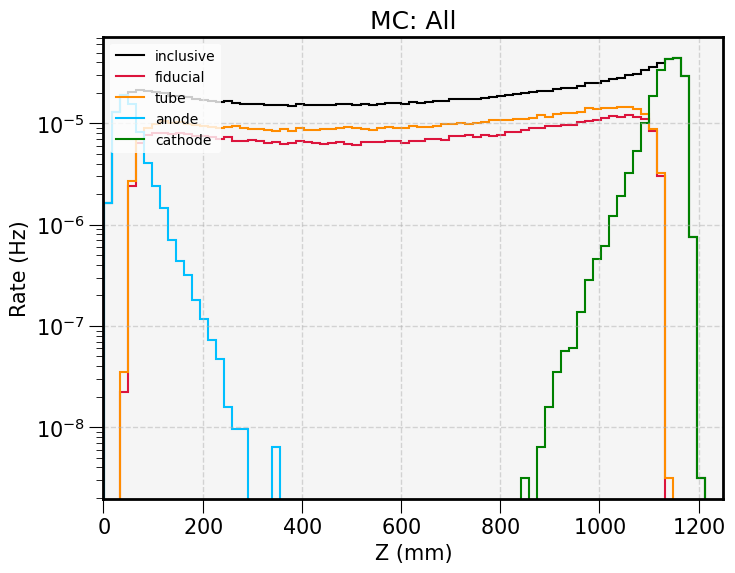

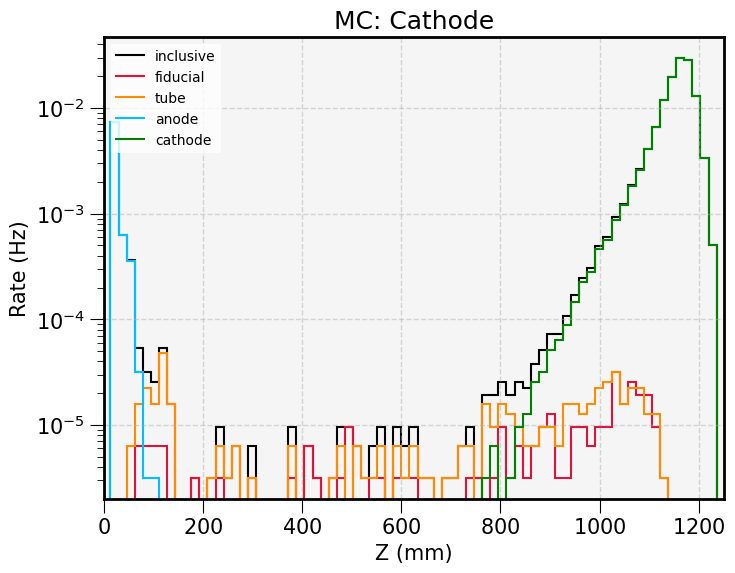

In [29]:
# Global
n_bins = 75
mc_names = ['All', 'Cathode']
regions  = ['inclusive', 'fiducial', 'tube', 'anode', 'cathode']

for i, dataframe in enumerate([ALL_EVTS_DF, CATH_EVTS_DF]):

    plt.figure(figsize=(8, 6))
    plt.title(f'MC: {mc_names[i]}')

    # Binning using "Inclusive" region
    _, Z_edges = np.histogram(dataframe['Z_bary'], bins=n_bins)

    for j, region in enumerate(regions):

        # Dataframe
        if region == 'inclusive':
            mc_region = dataframe.copy()
        else:
            mc_region = dataframe[dataframe['region'] == region].copy()

        # Variables
        Z = mc_region['Z_bary']

        # Histogram
        Z_counts, _ = np.histogram(Z, bins=Z_edges)
        Z_rate = Z_counts / (RUN_TIME_ALL if mc_names[i] == 'All' else RUN_TIME_CATH)

        # ----- Plotting ----- #
        plt.stairs(Z_rate, Z_edges, label=region, 
                   fill=False, lw=1.5, ec=pt.hist_colors[j % len(pt.hist_colors)])
 
    # ----- Styling ----- #
    plt.xlabel('Z (mm)')
    plt.xlim(0, 1250)
    plt.ylabel('Rate (Hz)')
    plt.yscale('log')
    plt.legend(loc='upper left', fontsize=10)
    plt.title(f'MC: {mc_names[i]}')
    plt.grid(True)
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### $E$ Distribution

First, let's see the energy distribution for $^{214}Bi$-MC @ cathode

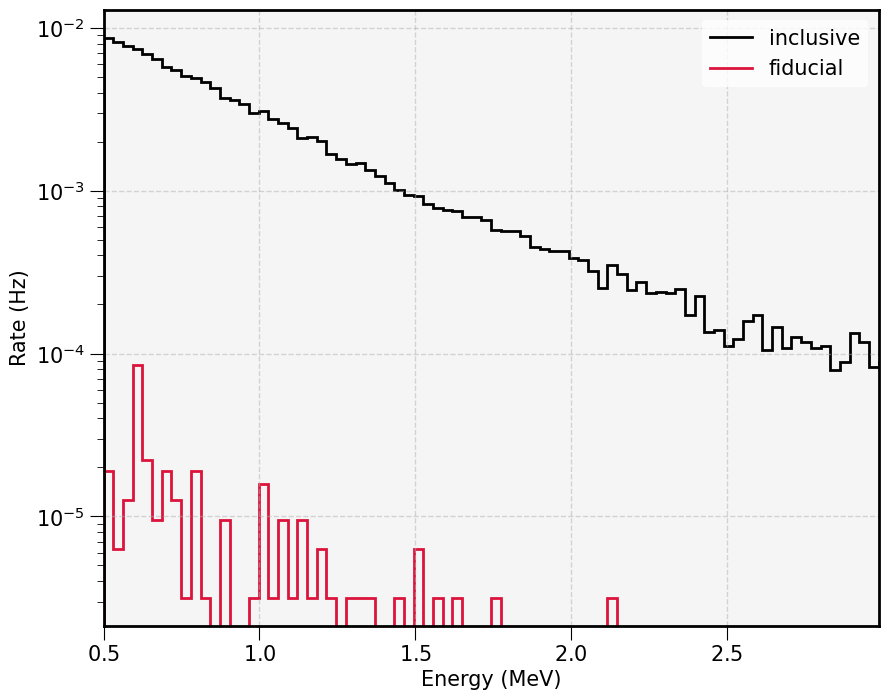

In [118]:
# Global
n_bins = 100
fig, ax = plt.subplots()

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(CATH_EVTS_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial']):

    # Dataframe
    if region == 'inclusive':
        mc_region = CATH_EVTS_DF.copy()
    else:
        mc_region = cath_fidu_evts_df.copy()

    # Variables
    E = mc_region['E_mev']

    # Histogram
    E_counts, _ = np.histogram(E, bins=E_edges)
    E_rate = E_counts / RUN_TIME_CATH

    # ----- Plotting ----- #
    plt.stairs(E_rate, E_edges, label=region, 
               fill=False, ec=pt.hist_colors[i % len(pt.hist_colors)], lw=2.0)
    
# plt.axvline(x=1.59, c='grey', ls='--', lw=1.0)        # DEP
    
# # ----- Styling ----- #
# # Important text
# plt.text(3.0, 4e-3, r'$R_{fiducial}$'f' = ({CATH_RATE_FIDU_CV*1e3:.2f} ± {CATH_RATE_FIDU_ERR*1e3:.2f}) mHz', va='center', ha='center')

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.8, 6e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum_Cathode_MC.pdf')
plt.show()

#### __All MC, but normalized to cathode rates__

At the same time, we obtain the rate (from cathode MC) and the events (from all MC) in the ROI


--- Processing Region: INCLUSIVE ---

INCLUSIVE events: 456269
Scale factor to Cathode MC: 0.093451 ± 0.000449
Scaled INCLUSIVE events: 42639.00
INCLUSIVE rate: 135.2074 mHz

--- Processing Region: FIDUCIAL ---

FIDUCIAL events: 162683
Scale factor to Cathode MC: 0.000602 ± 0.000061
Scaled FIDUCIAL events: 98.00
FIDUCIAL rate: 0.3108 mHz

--- ROI [2.4, 2.5] MeV Analysis for Region: FIDUCIAL ---
Unscaled events in ROI: 23
Scaled events in ROI: 0.0139 ± 0.0032
FIDUCIAL rate in ROI: (4.39e-08 ± 1.02e-08) Hz


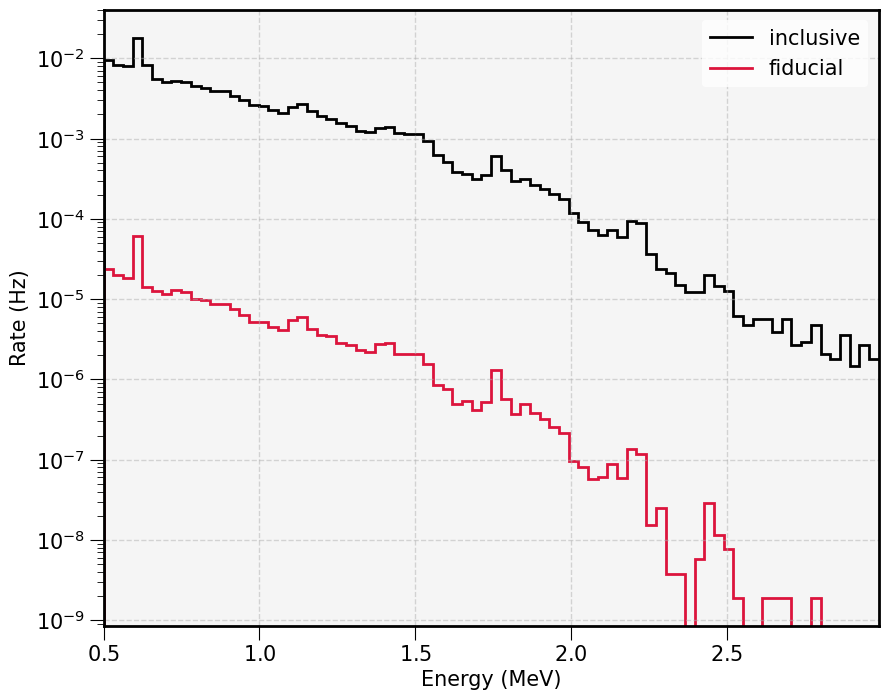

In [119]:
# Global
n_bins = 100
# ROI information
ROI_RATE_CV, ROI_RATE_ERR = 0, 0
ROI_EVTS_DF = pd.DataFrame()
fig, ax = plt.subplots()

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(ALL_EVTS_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial']):

    print(f"\n--- Processing Region: {region.upper()} ---")

    # Dataframe and cathode MC information
    if region == 'inclusive':
        mc_region = ALL_EVTS_DF.copy()
        evt_all_cv = Bi_INFO['All']['evt_incl_CV'];             evt_all_err = Bi_INFO['All']['evt_incl_Err']
        evt_cathode_cv  = Bi_INFO['Cathode']['evt_incl_CV'];    evt_cathode_err = Bi_INFO['Cathode']['evt_incl_Err']
    else:
        mc_region = all_fidu_evts_df.copy()
        evt_all_cv = Bi_INFO['All']['evt_fidu_CV'];             evt_all_err = Bi_INFO['All']['evt_fidu_Err']
        evt_cathode_cv  = Bi_INFO['Cathode']['evt_fidu_CV'];    evt_cathode_err = Bi_INFO['Cathode']['evt_fidu_Err']

    # Variables
    E = mc_region['E_mev']

    # ----- Normalized Histogram (by Cathode MC) ----- #
    E_counts, _ = np.histogram(E, bins=E_edges)
    print(f"\n{region.upper()} events: {E_counts.sum()}")
    # Computing the scale factor
    scale_factor_cv  = evt_cathode_cv / evt_all_cv
    scale_factor_err = scale_factor_cv * np.sqrt((evt_cathode_err/evt_cathode_cv)**2 + (evt_all_err/evt_all_cv)**2)
    print(f"Scale factor to Cathode MC: {scale_factor_cv:.6f} ± {scale_factor_err:.6f}")
    # Scale the counts
    E_counts_scaled = E_counts * scale_factor_cv
    E_rate = E_counts_scaled / RUN_TIME_CATH        # Importan to use the MC time exposure of cathode sample
    print(f"Scaled {region.upper()} events: {E_counts_scaled.sum():.2f}")
    print(f"{region.upper()} rate: {E_rate.sum()*1e3:.4f} mHz")

    # ----- Extract ROI Information (only Fiducial) ----- #
    if region == 'fiducial':

        print(f"\n--- ROI [{ROI_MIN}, {ROI_MAX}] MeV Analysis for Region: {region.upper()} ---")

        # ROI events dataframe
        ROI_EVTS_DF = mc_region[mc_region['E_mev'].between(ROI_MIN, ROI_MAX)].copy()    # Inclusive bounds

        # Events in ROI
        unscaled_counts_in_roi = ROI_EVTS_DF['global_event'].nunique()
        print(f"Unscaled events in ROI: {unscaled_counts_in_roi}")
        scaled_counts_in_roi_cv  = unscaled_counts_in_roi * scale_factor_cv
        scaled_counts_in_roi_err = scaled_counts_in_roi_cv * np.sqrt((1/unscaled_counts_in_roi) + (scale_factor_err/scale_factor_cv)**2)
        print(f"Scaled events in ROI: {scaled_counts_in_roi_cv:.4f} ± {scaled_counts_in_roi_err:.4f}")
        # ROI Rate, careful with the error propagation!
        ROI_RATE_CV = scaled_counts_in_roi_cv.sum() / RUN_TIME_CATH
        ROI_RATE_ERR = scaled_counts_in_roi_err.sum() / RUN_TIME_CATH
        print(f"{region.upper()} rate in ROI: ({ROI_RATE_CV:.2e} ± {ROI_RATE_ERR:.2e}) Hz")
        
    # ----- Plotting ----- #
    plt.stairs(E_rate, E_edges, label=region, 
               fill=False, ec=pt.hist_colors[i % len(pt.hist_colors)], lw=2.0)

# for x_peaks in [0.609, 1.120, 1.377, 1.764, 2.204, 2.447, 2.4, 2.5]:
#     plt.axvline(x=x_peaks, c='grey', ls='--', lw=1.0)
    
# # ----- Styling ----- #
# # Important text
# plt.text(2.5, 1.5e-3, r'$R_{fiducial}$'f' = ({CATH_RATE_FIDU_CV*1e3:.2f} ± {CATH_RATE_FIDU_ERR*1e3:.2f}) mHz', va='center', ha='center')

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.35, 3e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum_All_MC.pdf')
plt.show()

## Background Indices

#### Helper functions & detector values

In [ ]:
# ----- Fiducial Mass ----- #
volume_fid_CV, _ = pt.selection_volume(Z_UP - Z_LOW, 1, R_UP, 1)            # in mm3 - DO NOT USE THIS ERROR
volume_fid_CV /= 1e9                                                        # in m3
temp     = 293.15       # in [K]
pressure = 3.95         # in [bar]
R_gas    = 8.3145e-5    # in [m3·bar/(K·mol)]

# Use PV = nRT to calculate the number of moles
n_moles = (pressure * volume_fid_CV) / (R_gas * temp)    # in mol
print(f"Fiducial - number of moles = {n_moles:.4f} mol")
# Xenon molar mass
molar_mass_Xe = 135.9072    # in [g/mol]
MASS_FID_CV = n_moles * molar_mass_Xe / 1e3    # in [kg]
print(f"Fiducial - mass = {MASS_FID_CV:.4f} kg")

# ----- Background Index ----- #
def back_index(rate_hz: float, mass_kg: float, delta_e_mev: float) -> float:
    """
    Calculates the Background Index (BI).
    
    Parameters:
    - rate_hz: Rate in Hz.
    - mass_kg: Mass in kg.
    - delta_e_mev: Energy window in MeV.
    
    Returns:
    - BI in counts/(keV·kg·yr).
    """
    seconds_per_year = 31536000    # Number of seconds in a year
    rate_per_year = rate_hz * seconds_per_year
    delta_e_keV = delta_e_mev * 1e3
    bi = rate_per_year / (mass_kg * delta_e_keV)
    return bi

Fiducial - number of moles = 114.9668 mol
Fiducial - mass = 15.6248 kg


In [107]:
BACK_INDEX_ROI = back_index(ROI_RATE_CV, MASS_FID_CV, ROI_MAX - ROI_MIN)
print(f"Background Index in ROI: {BACK_INDEX_ROI:.2e} counts/(keV·kg·yr)")

Background Index in ROI: 8.87e-04 counts/(keV·kg·yr)


### Single-track

In [7]:
cath_fidu_evts_df['single_track'].value_counts()

yes    91
no      7
Name: single_track, dtype: int64

In [10]:
print(all_fidu_evts_df.global_event.nunique())
all_fidu_evts_df['single_track'].value_counts()

162683


yes    146420
no      16263
Name: single_track, dtype: int64

In [108]:
ROI_EVTS_DF['single_track'].value_counts()

yes    13
no     10
Name: single_track, dtype: int64

In [111]:
single_track_eff = ROI_EVTS_DF['single_track'].value_counts(normalize=True).get('yes', 0)
print(f"Single-track efficiency in ROI: {single_track_eff:.2%}")

BACK_INDEX_ROI_SINGLETRACK = BACK_INDEX_ROI * single_track_eff
print(f"Background Index in ROI after single-track cut: {BACK_INDEX_ROI_SINGLETRACK:.2e} counts/(keV·kg·yr)")

Single-track efficiency in ROI: 56.52%
Background Index in ROI after single-track cut: 5.01e-04 counts/(keV·kg·yr)
